In [179]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd
import pygmt

In [180]:
df = pd.read_csv('..\\..\\data\\age_hf\\lat_long_q_age.txt', sep='\t', header=None, 
                 names=['lat', 'lon', 'q', 'age'])
print(df.head())

     lat     lon      q       age
0  49.62 -129.98  366.0  0.816961
1  44.68 -125.29   79.0  9.119624
2  44.66 -125.27   81.0  9.119624
3  44.66 -125.27   93.0  9.119624
4  44.66 -125.26   77.0  9.119624


now we get depth from formula 21 and heat flow from form 23

In [181]:
ihfc_qt = []
dt = []
sqrt_age = []
ps_qt = []

for q in df['q']:
    ihfc_qt.append(q*0.0238846)  # mW/m^2 --> μcal/cm^2*s

for a in df['age']:
    sqrt_age.append(a**(0.5))
    dt.append(2500 + 350*(a**(0.5)))
    ps_qt.append(11.3/a**(0.5))

print(dt[:2], sqrt_age[:2])
print(ihfc_qt[:2], ps_qt[:2])

[2816.350676741808, 3556.955037951] [0.9038590764051662, 3.019871537002857]
[8.741763599999999, 1.8868833999999999] [12.501948915468581, 3.741881024255407]


In [182]:
a = 125  # km
T1 = 1333  # C
alpha = 3.28e-5  # 1/C
conduct = 7.5e-3  # cal/C*cm*s
density_o = 3.33  # g/cm^3, density of oceanic crust/litho
density_w = 1.0  # g/cm^3, density of water 
Cp = 0.28  # cal/g*C, specific heat
diffuse = conduct/(density_o*Cp)  # cal/C*cm*s

c4 = density_o*Cp*T1*(diffuse/np.pi)**(0.5)

print(f'c4: {c4}')

c5 = (0.22*(a)**(0.5))/diffuse

print(f'c5: {c5}')

c6 = (conduct * T1)/a  

print(f'c6: {c6} μcal/cm^2*s')

c4: 62.890779436346214
c5: 305.7867680590513
c6: 0.07998000000000001 μcal/cm^2*s


fig 5 c.. this is all screwed up

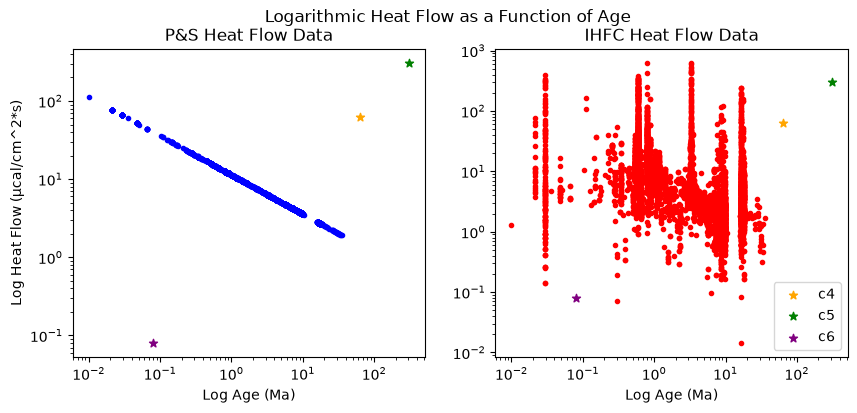

In [229]:
fig0, (ax0, ax1) = plt.subplots(1,2,figsize=(10, 4))
ax0.loglog(df['age'], ps_qt, marker='o', color='blue', linestyle='None', markersize=3)
ax0.scatter(c4, c4, marker='*', color='orange', label='c4')
ax0.scatter(c5, c5, marker='*', color='green', label='c5')
ax0.scatter(c6, c6, marker='*', color='purple', label='c6')
ax0.set_xlabel('Log Age (Ma)')
ax0.set_ylabel('Log Heat Flow (μcal/cm^2*s)')
ax0.set_title('P&S Heat Flow Data')


ax1.loglog(df['age'], ihfc_qt, marker='o', color='red', linestyle='None', markersize=3)
ax1.scatter(c4, c4, marker='*', color='orange', label='c4')
ax1.scatter(c5, c5, marker='*', color='green', label='c5')
ax1.scatter(c6, c6, marker='*', color='purple', label='c6')
ax1.set_xlabel('Log Age (Ma)')
ax1.set_title('IHFC Heat Flow Data')


fig0.suptitle('Logarithmic Heat Flow as a Function of Age')
plt.legend()
plt.show()

In [233]:
slope, intercept = np.polyfit(df['age'], ps_qt, 1)
print(f"P&S Slope: {slope} and Intercept: {intercept}")

slope, intercept = np.polyfit(df['age'], ihfc_qt, 1)
print(f"IHFC Slope: {slope} and Intercept: {intercept}")

P&S Slope: -0.9124643863486798 and Intercept: 14.859229834591506
IHFC Slope: -1.167145600750884 and Intercept: 21.82489634637974


fig 8 a

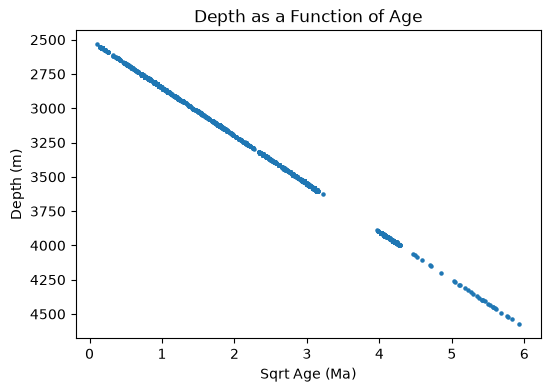

In [234]:
fig1, ax1 = plt.subplots(figsize=(6, 4))
ax1.scatter(sqrt_age, dt, marker='o', s=5)
ax1.set_xlabel('Sqrt Age (Ma)')
ax1.set_ylabel('Depth (m)')
ax1.set_title('Depth as a Function of Age')
ax1.invert_yaxis()
plt.show()

fig 10

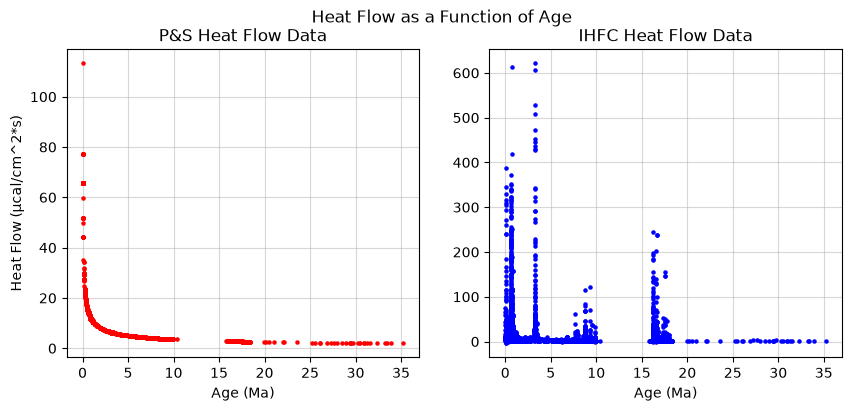

In [235]:
fig2, (ax2, ax3) = plt.subplots(1, 2, figsize=(10, 4))

ax2.scatter(df['age'], ps_qt, marker='o', color='red', s=5)
ax2.set_xlabel('Age (Ma)')
ax2.set_ylabel('Heat Flow (μcal/cm^2*s)')
ax2.set_title('P&S Heat Flow Data')
ax2.set_axisbelow(True)
ax2.grid(alpha=0.5)

ax3.scatter(df['age'], ihfc_qt, marker='o',color='blue', s=5)
ax3.set_xlabel('Age (Ma)')
# ax3.set_ylabel('Heat Flow (μcal/cm^2*s)')
ax3.set_title('IHFC Heat Flow Data')
ax3.set_axisbelow(True)
plt.grid(alpha=0.5)

fig2.suptitle('Heat Flow as a Function of Age')


plt.show()

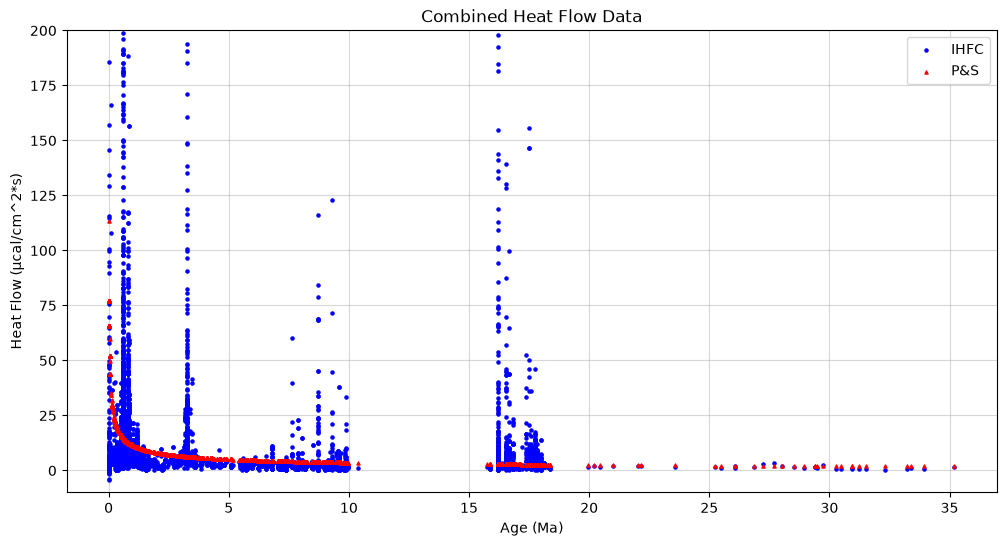

In [236]:
fig3, ax4 = plt.subplots(figsize=(12, 6))

ax4.scatter(df['age'], ihfc_qt, marker='o',color='blue', s=5, label='IHFC')
ax4.scatter(df['age'], ps_qt, marker='^', color='red', s=5, label='P&S')
ax4.set_ylim(-10, 200)
ax4.set_xlabel('Age (Ma)')
ax4.set_ylabel('Heat Flow (μcal/cm^2*s)')
ax4.set_title('Combined Heat Flow Data')
ax4.set_axisbelow(True)

plt.grid(alpha=0.5)
plt.legend()
plt.show()